# Fictional support arm

Imagine a small arm sticking out from a wall. Its left end is fixed
to the wall. A downward force pulls on its free right end.

| Input | Symbol | Invented value |
|---|---|---|
| Length from wall to free end | L | 300 mm |
| Width | b | 50 mm |
| Vertical thickness | h | 10 mm |
| Downward force at free end | F | 100 N |
| Support condition | — | Left end fixed; right end free |

![Fictional support arm](../figures/06_support_geometry.png)

These dimensions and the force are invented for this educational project.
I will use the same shape and force when comparing both materials.
I will leave out the arm's own weight from the later bending calculation.

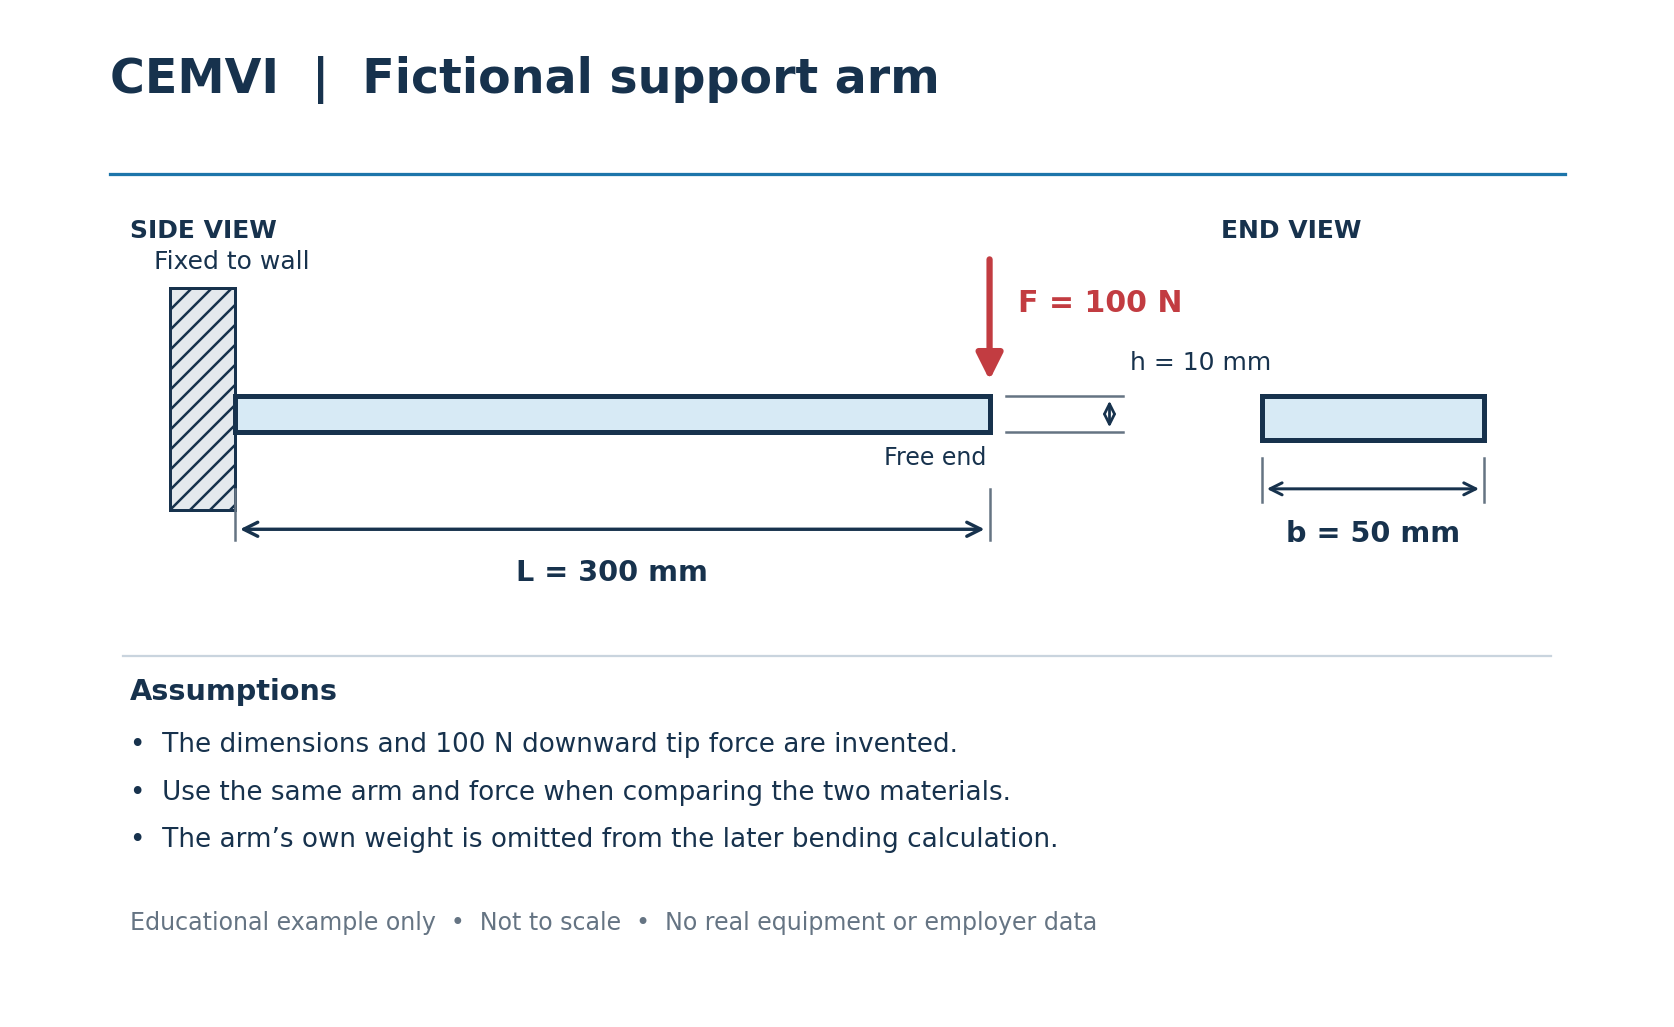

In [1]:
from pathlib import Path
from IPython.display import Image, display

possible_paths = [
    Path("../figures/06_support_geometry.png"),
    Path("figures/06_support_geometry.png"),
]

image_path = next((path for path in possible_paths if path.is_file()), None)

if image_path is None:
    print("Image not found. Python is looking from:", Path.cwd())
else:
    display(Image(filename=str(image_path)))

# Material properties

I will compare the same fictional support arm made from two materials.
Density tells me how much mass fits into a given volume. Young's modulus
tells me how strongly a material resists elastic stretching or bending.

| Material | Density, ρ (kg/m³) | Young's modulus, E (GPa) |
|---|---:|---:|
| Outokumpu Core 304/4301 stainless steel | 7,900 | 200 |
| Hydro EN AW-6060-T6 aluminium | 2,700 | 69 |

These material values come from public manufacturer datasheets; I did
not invent them. The arm's dimensions and 100 N force remain invented.

# Mass comparison

First, convert the invented dimensions from millimetres to metres:

- Length = 300 mm = 0.300 m
- Width = 50 mm = 0.050 m
- Thickness = 10 mm = 0.010 m

Volume = length × width × thickness
= 0.300 × 0.050 × 0.010
= 0.000150 m³

Mass = density × volume

- Steel mass = 7,900 × 0.000150 = 1.185 kg
- Aluminium mass = 2,700 × 0.000150 = 0.405 kg
- Difference = 1.185 − 0.405 = 0.780 kg
- Aluminium mass reduction = (0.780 ÷ 1.185) × 100 = 65.82%

This calculates the mass of the arm alone. The invented 100 N downward
force is a separate load, so it does not enter this mass calculation.

In [2]:
# Mass of two identical support arms made from different materials

length_m = 300 / 1000
width_m = 50 / 1000
thickness_m = 10 / 1000

volume_m3 = length_m * width_m * thickness_m

steel_density = 7900       # kg/m³, from earlier source
aluminium_density = 2700   # kg/m³, from earlier source

steel_mass = steel_density * volume_m3
aluminium_mass = aluminium_density * volume_m3

difference = steel_mass - aluminium_mass
reduction_percent = difference / steel_mass * 100

print(f"Arm volume: {volume_m3:.6f} m³")
print(f"Steel arm mass: {steel_mass:.3f} kg")
print(f"Aluminium arm mass: {aluminium_mass:.3f} kg")
print(f"Mass difference: {difference:.3f} kg")
print(f"Aluminium mass reduction: {reduction_percent:.2f}%")

Arm volume: 0.000150 m³
Steel arm mass: 1.185 kg
Aluminium arm mass: 0.405 kg
Mass difference: 0.780 kg
Aluminium mass reduction: 65.82%


# Bending comparison

The arm is fixed at one end, and a 100 N force pulls downward at
its free tip. I use a simple elastic cantilever-beam model.

The vertical thickness is h = 0.010 m and the width is b = 0.050 m.

Second moment of area:
I = b × h³ ÷ 12
I = 0.050 × 0.010³ ÷ 12
I = 0.000000004167 m⁴

Tip deflection:
deflection = F × L³ ÷ (3 × E × I)

Steel, E = 200,000,000,000 Pa:
deflection = 100 × 0.300³ ÷
             (3 × 200,000,000,000 × 0.000000004167)
           ≈ 0.00108 m = 1.08 mm

Aluminium, E = 69,000,000,000 Pa:
deflection = 100 × 0.300³ ÷
             (3 × 69,000,000,000 × 0.000000004167)
           ≈ 0.00313 m = 3.13 mm

Tip stiffness = force ÷ tip deflection

- Steel: 100 ÷ 1.08 ≈ 92.59 N/mm
- Aluminium: 100 ÷ 3.13 ≈ 31.94 N/mm

In [3]:
# Fictional support-arm bending comparison

length_m = 0.300
width_m = 0.050
thickness_m = 0.010
force_n = 100

steel_E_pa = 200e9
aluminium_E_pa = 69e9

I_m4 = width_m * thickness_m**3 / 12

steel_deflection_m = (
    force_n * length_m**3 / (3 * steel_E_pa * I_m4)
)
aluminium_deflection_m = (
    force_n * length_m**3 / (3 * aluminium_E_pa * I_m4)
)

steel_deflection_mm = steel_deflection_m * 1000
aluminium_deflection_mm = aluminium_deflection_m * 1000

steel_stiffness_n_per_mm = force_n / steel_deflection_mm
aluminium_stiffness_n_per_mm = force_n / aluminium_deflection_mm

print(f"Second moment of area: {I_m4:.9e} m⁴")
print(f"Steel tip deflection: {steel_deflection_mm:.2f} mm")
print(f"Aluminium tip deflection: {aluminium_deflection_mm:.2f} mm")
print(f"Steel tip stiffness: {steel_stiffness_n_per_mm:.2f} N/mm")
print(f"Aluminium tip stiffness: {aluminium_stiffness_n_per_mm:.2f} N/mm")

Second moment of area: 4.166666667e-09 m⁴
Steel tip deflection: 1.08 mm
Aluminium tip deflection: 3.13 mm
Steel tip stiffness: 92.59 N/mm
Aluminium tip stiffness: 31.94 N/mm


## Result

For the same shape and 100 N force, the steel arm's tip moves about
1.08 mm, while the aluminium arm's tip moves about 3.13 mm.
The aluminium arm is lighter, but it bends more in this simplified model.

This assumes a perfectly fixed end, elastic bending, and no bending
from the arm's own weight. It does not prove that either arm is suitable
for real equipment.

# Bending stress

The 100 N force acts 0.300 m from the wall.

Maximum bending moment at the wall:
M = force × length = 100 × 0.300 = 30 N·m

Distance from the centre to the top or bottom surface:
c = thickness ÷ 2 = 0.010 ÷ 2 = 0.005 m

From Second moment of area:
I = 4.166667 × 10⁻⁹ m⁴

Maximum nominal bending stress:
stress = M × c ÷ I
       = 30 × 0.005 ÷ (4.166667 × 10⁻⁹)
       = 36,000,000 Pa
       = 36 MPa

Unit check:
(N·m × m) ÷ m⁴ = N/m² = Pa

The calculated bending stress is 36 MPa for both materials because
their shape and the applied force are the same. Their different
Young's modulus values explain why they bent by different amounts.

In [4]:
# Nominal bending stress at the fixed end

force_n = 100
length_m = 0.300
width_m = 0.050
thickness_m = 0.010

I_m4 = width_m * thickness_m**3 / 12
moment_nm = force_n * length_m
outer_distance_m = thickness_m / 2

stress_pa = moment_nm * outer_distance_m / I_m4
stress_mpa = stress_pa / 1_000_000

# A second form of the same equation checks the arithmetic.
check_mpa = (
    6 * force_n * length_m / (width_m * thickness_m**2)
) / 1_000_000

print(f"Moment at wall: {moment_nm:.2f} N·m")
print(f"Nominal bending stress, steel: {stress_mpa:.2f} MPa")
print(f"Nominal bending stress, aluminium: {stress_mpa:.2f} MPa")
print(f"Arithmetic check: {check_mpa:.2f} MPa")

Moment at wall: 30.00 N·m
Nominal bending stress, steel: 36.00 MPa
Nominal bending stress, aluminium: 36.00 MPa
Arithmetic check: 36.00 MPa


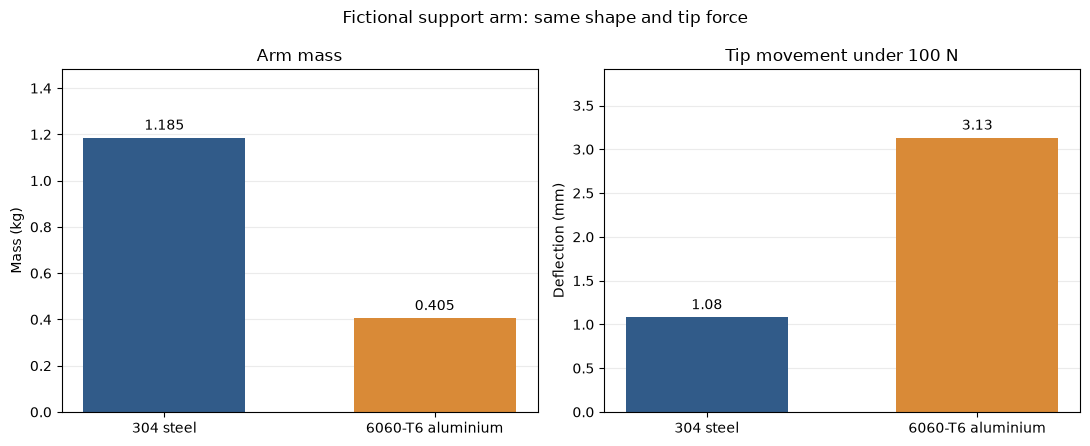

304 steel: 1.185 kg, 1.08 mm, 92.59 N/mm
6060-T6 aluminium: 0.405 kg, 3.13 mm, 31.94 N/mm
Graph saved: 07_material_tradeoff.png


In [5]:
from pathlib import Path
import matplotlib.pyplot as plt

# Invented arm and force
force_n = 100
length_m = 0.300
width_m = 0.050
thickness_m = 0.010

# Published material properties recorded
names = ["304 steel", "6060-T6 aluminium"]
colors = ["#315b89", "#d98a37"]
densities = [7900, 2700]        # kg/m³
moduli_pa = [200e9, 69e9]       # Pa

volume_m3 = length_m * width_m * thickness_m
I_m4 = width_m * thickness_m**3 / 12

masses_kg = [density * volume_m3 for density in densities]
deflections_mm = [
    force_n * length_m**3 / (3 * modulus * I_m4) * 1000
    for modulus in moduli_pa
]
stiffness_n_per_mm = [
    force_n / deflection for deflection in deflections_mm
]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, values, title, y_label, number_format in [
    (axes[0], masses_kg, "Arm mass", "Mass (kg)", "{:.3f}"),
    (axes[1], deflections_mm, "Tip movement under 100 N",
     "Deflection (mm)", "{:.2f}"),
]:
    ax.bar(names, values, color=colors, width=0.6)
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, max(values) * 1.25)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    for index, value in enumerate(values):
        ax.text(index, value + max(values) * 0.03,
                number_format.format(value), ha="center")

fig.suptitle("Fictional support arm: same shape and tip force")
fig.tight_layout()

# Find the project's existing figures folder
figures_dir = Path("figures")
if not figures_dir.is_dir():
    figures_dir = Path("../figures")
if not figures_dir.is_dir():
    raise FileNotFoundError("The figures folder could not be found.")

graph_path = figures_dir / "07_material_tradeoff.png"
fig.savefig(graph_path, dpi=150, bbox_inches="tight")
plt.show()

for name, mass, deflection, stiffness in zip(
    names, masses_kg, deflections_mm, stiffness_n_per_mm
):
    print(
        f"{name}: {mass:.3f} kg, {deflection:.2f} mm, "
        f"{stiffness:.2f} N/mm"
    )

print("Graph saved:", graph_path.name)

# Material comparison

| Fictional arm material | Mass (kg) | Tip deflection (mm) | Tip stiffness (N/mm) | Nominal bending stress (MPa) |
|---|---:|---:|---:|---:|
| Core 304/4301 steel | 1.185 | 1.08 | 92.59 | 36 |
| EN AW-6060-T6 aluminium | 0.405 | 3.13 | 31.94 | 36 |

For identical dimensions, the aluminium arm has 0.780 kg less mass
(65.82% less than the steel arm). Under the same 100 N force, its tip
moves about 2.90 times as far. The steel arm is heavier and has greater
tip stiffness. The simplified nominal bending stress is 36 MPa for
both because the force and geometry are identical.

This comparison does not include the arm's own weight, bolts,
movement of the wall, vibration, temperature changes, corrosion,
manufacturing, cost, or an allowable deflection. It does not establish
that either material is suitable for a real support.